# **DATA**

In [ ]:
import pandas as pd

df = pd.read_csv("18sat_fixfinal.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463564 entries, 0 to 463563
Data columns (total 29 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   RECORDING_SESSION_LABEL               463564 non-null  object 
 1   TRIAL_INDEX                           463564 non-null  int64  
 2   CURRENT_FIX_X                         463564 non-null  float64
 3   CURRENT_FIX_Y                         463564 non-null  float64
 4   CURRENT_FIX_PUPIL                     463564 non-null  float64
 5   CURRENT_FIX_DURATION                  463564 non-null  int64  
 6   CURRENT_FIX_INTEREST_AREA_ID          251087 non-null  float64
 7   CURRENT_FIX_INTEREST_AREA_LABEL       251087 non-null  object 
 8   CURRENT_FIX_INTEREST_AREA_PIXEL_AREA  251087 non-null  float64
 9   CURRENT_FIX_INTEREST_AREA_RUN_ID      251087 non-null  float64
 10  CURRENT_FIX_INTEREST_AREA_DWELL_TIME  251087 non-null  float64
 11  

In [ ]:
# Handle missing blink data (null duration implies 0ms)
df['PREVIOUS_SAC_BLINK_DURATION'] = df['PREVIOUS_SAC_BLINK_DURATION'].fillna(0)

# Standardize blink indicators to a binary (1 or 0) format for the network
df['PREVIOUS_SAC_CONTAINS_BLINK'] = (
    df['PREVIOUS_SAC_CONTAINS_BLINK']
    .astype(str)
    .str.lower()
    .map({'true': 1, 'false': 0, '1': 1, '0': 0})
    .fillna(0)
    .astype(int)
)

In [ ]:
# Remove administrative data and categorical labels which are not used by the sequential Bi-LSTM
cols_to_drop = [
    'Session_Name_',
    'Trial_Index_',
    'Trial_Recycled_',
    'page_name',
    'book_name',
    'CURRENT_FIX_INTEREST_AREA_LABEL',
    'CURRENT_FIX_INTEREST_AREA_PIXEL_AREA',
    'TRIAL_INDEX',
    'total_page'
]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

In [ ]:
# Extracting comprehension question events and evaluating the accuracy
question_mask = df['type'].str.lower() == 'question'
df.loc[question_mask, 'is_correct'] = (df.loc[question_mask, 'answer'].astype(str) == df.loc[question_mask, 'correct_answer'].astype(str)).astype(float)
unique_answers = df[question_mask].drop_duplicates(subset=['RECORDING_SESSION_LABEL', 'book', 'page'])

# Aggregate total correct answers per participant-book pair
accuracy_scores = unique_answers.groupby(['RECORDING_SESSION_LABEL', 'book'])['is_correct'].sum().reset_index()

# Normalizing to a 0-1 range (each text has exactly 5 comprehension questions)
accuracy_scores['is_correct'] /= 5.0
accuracy_scores.rename(columns={'is_correct': 'target_accuracy'}, inplace=True)

# Mapping the computed regression target back to all chronological reading frames
if 'target_accuracy' in df.columns:
    df = df.drop(columns=['target_accuracy'])
df = df.merge(accuracy_scores, on=['RECORDING_SESSION_LABEL', 'book'], how='left')

### LSTM preparations

In [ ]:
# One-hot encoding categorical saccade directions for network compatibility
df = pd.get_dummies(df, columns=['PREVIOUS_SAC_DIRECTION'], dummy_na=True, dtype=int)

# Dropping intermediate answer features to prevent target leakage during training
df = df.drop(columns=['answer', 'correct_answer', 'is_correct'])

In [ ]:
# Enforcing strict chronological alignment for temporal feature engineering
df = df.sort_values(by=['RECORDING_SESSION_LABEL', 'book', 'page'])

# Aggregating cumulative saccade directions per reading section
saccade_cols = [c for c in df.columns if c.startswith('PREVIOUS_SAC_DIRECTION_')]
for col in saccade_cols:
    df[f'total_{col}'] = df.groupby(['RECORDING_SESSION_LABEL', 'book', 'page'])[col].transform('sum')

# Computing blink frequencies and duration-normalized blink rates
df['total_blinks'] = df.groupby(['RECORDING_SESSION_LABEL', 'book', 'page'])['PREVIOUS_SAC_CONTAINS_BLINK'].transform('sum')
df['blink_rate_by_RT'] = df['total_blinks'] / (df['RT'] + 1e-6)  #Epsilon og 1e-6 added for numerical stability

# Aggregating overall fixation dwell time
df['total_dwell_time'] = df.groupby(['RECORDING_SESSION_LABEL', 'book', 'page'])['CURRENT_FIX_DURATION'].transform('sum')

# Calculating temporal pupil dilation delta (proxy for localized cognitive load)
df['pupil_change'] = df.groupby(['RECORDING_SESSION_LABEL', 'book', 'page'])['CURRENT_FIX_PUPIL'].diff().fillna(0)

In [ ]:
feature_categories = {
    'pupil': [
        'CURRENT_FIX_PUPIL',
        'pupil_change'
    ],
    'fixation': [
        'CURRENT_FIX_X',
        'CURRENT_FIX_Y',
        'CURRENT_FIX_DURATION',
        'CURRENT_FIX_INTEREST_AREA_ID',
        'CURRENT_FIX_INTEREST_AREA_RUN_ID',
        'CURRENT_FIX_INTEREST_AREA_DWELL_TIME',
        'total_dwell_time'
    ],
    'blink': [
        'PREVIOUS_SAC_CONTAINS_BLINK',
        'PREVIOUS_SAC_BLINK_DURATION',
        'total_blinks',
        'blink_rate_by_RT'
    ],
    'saccade': [
        'PREVIOUS_SAC_ANGLE',
        'PREVIOUS_SAC_AMPLITUDE',
        'PREVIOUS_SAC_AVG_VELOCITY'
    ] ,
    'RT': [
        'RT'
    ]
}

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Flattening hierarchical feature dictionary and replacing nulls with 0s to maintain matrix integrity
all_features = [feat for category in feature_categories.values() for feat in category]
df[all_features] = df[all_features].fillna(0)
df = df.dropna(subset=['target_accuracy'])

# Implementing the "Unseen Reader" evaluation regime
participants = df['RECORDING_SESSION_LABEL'].unique()
train_subs, test_subs = train_test_split(participants, test_size=0.2, random_state=42)
train_df = df[df['RECORDING_SESSION_LABEL'].isin(train_subs)].copy()
test_df = df[df['RECORDING_SESSION_LABEL'].isin(test_subs)].copy()

# Standardizing features
scaler = StandardScaler()
train_df[all_features] = scaler.fit_transform(train_df[all_features])
test_df[all_features] = scaler.transform(test_df[all_features])


def build_sequences_and_targets(dataframe):
  """Groups sequential reading frames by session and book into 2D arrays."""
  seqs, targs, grps = [], [], []
  for (session, book), group_df in dataframe.groupby(['RECORDING_SESSION_LABEL', 'book']):
    seq_array = group_df[all_features].values
    target = group_df['target_accuracy'].iloc[0]
    seqs.append(seq_array)
    targs.append(target)
    grps.append(session)
  return seqs, targs, grps

train_seqs, train_targets, train_groups = build_sequences_and_targets(train_df)
test_seqs, test_targets, test_groups = build_sequences_and_targets(test_df)

MASK_VALUE = -999.0
# Padding varying-length reading sequences into uniform 3D tensors (samples, timesteps, features)
X_train_padded = pad_sequences(train_seqs, padding='post', dtype='float32', value=MASK_VALUE)
y_train = np.array(train_targets, dtype='float32')
groups_train = np.array(train_groups)

X_test_padded = pad_sequences(test_seqs, padding='post', dtype='float32', value=MASK_VALUE)
y_test = np.array(test_targets, dtype='float32')
groups_test = np.array(test_groups)

print(f"Final Train Shape (X): {X_train_padded.shape}")
print(f"Final Target Shape (y_train): {y_train.shape}")
print(f"Final Test Shape (X): {X_test_padded.shape}")
print(f"Final Target Shape (y_test): {y_test.shape}")

Final Train Shape (X): (304, 2907, 17)
Final Target Shape (y_train): (304,)
Final Test Shape (X): (76, 1894, 17)
Final Target Shape (y_test): (76,)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 463564 entries, 0 to 460776
Data columns (total 32 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   RECORDING_SESSION_LABEL               463564 non-null  object 
 1   CURRENT_FIX_X                         463564 non-null  float64
 2   CURRENT_FIX_Y                         463564 non-null  float64
 3   CURRENT_FIX_PUPIL                     463564 non-null  float64
 4   CURRENT_FIX_DURATION                  463564 non-null  int64  
 5   CURRENT_FIX_INTEREST_AREA_ID          463564 non-null  float64
 6   CURRENT_FIX_INTEREST_AREA_RUN_ID      463564 non-null  float64
 7   CURRENT_FIX_INTEREST_AREA_DWELL_TIME  463564 non-null  float64
 8   PREVIOUS_SAC_ANGLE                    463564 non-null  float64
 9   PREVIOUS_SAC_AMPLITUDE                463564 non-null  float64
 10  PREVIOUS_SAC_AVG_VELOCITY             463564 non-null  float64
 11  PREVI

In [ ]:
df

,RECORDING_SESSION_LABEL,CURRENT_FIX_X,CURRENT_FIX_Y,CURRENT_FIX_PUPIL,CURRENT_FIX_DURATION,CURRENT_FIX_INTEREST_AREA_ID,CURRENT_FIX_INTEREST_AREA_RUN_ID,CURRENT_FIX_INTEREST_AREA_DWELL_TIME,PREVIOUS_SAC_ANGLE,PREVIOUS_SAC_AMPLITUDE,...,PREVIOUS_SAC_DIRECTION_nan,total_PREVIOUS_SAC_DIRECTION_DOWN,total_PREVIOUS_SAC_DIRECTION_LEFT,total_PREVIOUS_SAC_DIRECTION_RIGHT,total_PREVIOUS_SAC_DIRECTION_UP,total_PREVIOUS_SAC_DIRECTION_nan,total_blinks,blink_rate_by_RT,total_dwell_time,pupil_change
0,msd001,59.8,125.4,1430.0,22,0.0,0.0,0.0,0.00,0.00,...,1,6,66,138,6,4,9,0.000359,39813,0.0
1,msd001,348.7,182.0,1375.0,26,24.0,1.0,364.0,-11.72,8.47,...,0,6,66,138,6,4,9,0.000359,39813,-55.0
2,msd001,630.5,400.3,1365.0,216,72.0,1.0,364.0,-37.61,10.68,...,0,6,66,138,6,4,9,0.000359,39813,-10.0
3,msd001,492.0,400.2,1440.0,125,69.0,1.0,315.0,177.50,3.89,...,0,6,66,138,6,4,9,0.000359,39813,75.0
4,msd001,526.6,390.5,1265.0,486,70.0,1.0,1040.0,32.75,0.79,...,0,6,66,138,6,4,9,0.000359,39813,-175.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
460772,msd107,634.2,253.7,1235.0,110,0.0,0.0,0.0,-3.68,3.34,...,0,2,1,2,3,2,1,0.000392,1411,-5.0
460773,msd107,568.2,401.7,1266.0,154,0.0,0.0,0.0,-113.91,4.20,...,0,2,1,2,3,2,1,0.000392,1411,31.0
460774,msd107,584.9,398.5,1276.0,253,0.0,0.0,0.0,4.08,0.46,...,1,2,1,2,3,2,1,0.000392,1411,10.0
460775,msd107,593.4,454.5,1262.0,132,0.0,0.0,0.0,-80.82,1.92,...,0,2,1,2,3,2,1,0.000392,1411,-14.0


# **PART A - Models' Development**

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Masking, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import GroupKFold

def rmse(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(y_pred - y_true)))

# Constructing the Bi-LSTM regression architecture (adapted from Ahn et al.)
def build_ahn_rnn_keras(timesteps, features):
    model = Sequential()
    model.add(Input(shape=(timesteps, features)))
    model.add(Masking(mask_value=-999.0))
    model.add(Bidirectional(LSTM(64, return_sequences=False)))
    model.add(Dropout(0.3))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(50, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='mse',
                  metrics=['mae', rmse])
    return model

# Regularization via early stopping based on validation loss
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
gkf = GroupKFold(n_splits=5)
fold = 1
fold_results = []
timesteps = X_train_padded.shape[1]
features = X_train_padded.shape[2]
print("Starting 5-Fold Cross Validation for Baseline AhnRNN...")

for train_idx, val_idx in gkf.split(X_train_padded, y_train, groups=groups_train):
    print(f"\n--- Starting Fold {fold} ---")
    X_train_fold = X_train_padded[train_idx]
    y_train_fold = y_train[train_idx]
    X_val_fold = X_train_padded[val_idx]
    y_val_fold = y_train[val_idx]
    print(f"Training on {len(X_train_fold)} sequences, Validating on {len(X_val_fold)} sequences.")
    model = build_ahn_rnn_keras(timesteps, features)

    history = model.fit(
        X_train_fold,
        y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=15,
        batch_size=32,
        verbose=1,
        callbacks=[early_stop]
    )
    val_loss, val_mae, val_rmse = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    print(f"Fold {fold} Results -> RMSE: {val_rmse:.4f}, MAE: {val_mae:.4f}")
    fold_results.append((val_rmse, val_mae))
    fold += 1

avg_rmse = np.mean([res[0] for res in fold_results])
avg_mae = np.mean([res[1] for res in fold_results])

print(f"\n=== OVERALL BASELINE RESULTS ===")
print(f"Average RMSE: {avg_rmse:.4f}")
print(f"Average MAE: {avg_mae:.4f}")

Starting 5-Fold Cross Validation for Baseline AhnRNN...

--- Starting Fold 1 ---
Training on 240 sequences, Validating on 64 sequences.
Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 202ms/step - loss: 0.0558 - mae: 0.1940 - rmse: 0.2280 - val_loss: 0.0660 - val_mae: 0.2031 - val_rmse: 0.2572
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - loss: 0.0528 - mae: 0.1863 - rmse: 0.2341 - val_loss: 0.0649 - val_mae: 0.2003 - val_rmse: 0.2572
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - loss: 0.0522 - mae: 0.1874 - rmse: 0.2344 - val_loss: 0.0661 - val_mae: 0.2049 - val_rmse: 0.2585
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - loss: 0.0513 - mae: 0.1854 - rmse: 0.2359 - val_loss: 0.0679 - val_mae: 0.2067 - val_rmse: 0.2586
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 209ms/step - loss: 0.0509 - mae: 0.1837 - rmse: 0.2372 - val_loss: 0.0689 - val_mae: 0.2092 - val_rmse: 0.2603
Fold 1 Results -> RMSE: 0.2572, MAE: 0.2003

--- Starting Fold 2 ---
Training on 244 sequences, Validating on 60 

In [ ]:
from sklearn.decomposition import PCA

pupil_blink_features = [
    'CURRENT_FIX_PUPIL', 'pupil_change',
    'PREVIOUS_SAC_CONTAINS_BLINK', 'PREVIOUS_SAC_BLINK_DURATION',
    'total_blinks', 'blink_rate_by_RT'
]
fixation_features = [
    'CURRENT_FIX_X', 'CURRENT_FIX_Y', 'CURRENT_FIX_DURATION',
    'CURRENT_FIX_INTEREST_AREA_ID', 'CURRENT_FIX_INTEREST_AREA_RUN_ID',
    'CURRENT_FIX_INTEREST_AREA_DWELL_TIME', 'total_dwell_time', 'RT'
]
saccade_dir_cols = [col for col in df.columns if col.startswith('PREVIOUS_SAC_DIRECTION_')]
total_dir_cols = [col for col in df.columns if col.startswith('total_PREVIOUS_SAC_DIRECTION_')]
saccade_features = [
    'PREVIOUS_SAC_ANGLE', 'PREVIOUS_SAC_AMPLITUDE', 'PREVIOUS_SAC_AVG_VELOCITY'
] + saccade_dir_cols + total_dir_cols

pca_pupil = PCA(n_components=1)
pca_fix = PCA(n_components=1)
pca_sac = PCA(n_components=1)
train_df['pca_pupil_blink'] = pca_pupil.fit_transform(train_df[pupil_blink_features])
test_df['pca_pupil_blink'] = pca_pupil.transform(test_df[pupil_blink_features])
train_df['pca_fixation'] = pca_fix.fit_transform(train_df[fixation_features])
test_df['pca_fixation'] = pca_fix.transform(test_df[fixation_features])
train_df['pca_saccade'] = pca_sac.fit_transform(train_df[saccade_features])
test_df['pca_saccade'] = pca_sac.transform(test_df[saccade_features])

pca_features = ['pca_pupil_blink', 'pca_fixation', 'pca_saccade']

def build_pca_sequences_and_targets(dataframe):
    seqs, targs, grps = [], [], []
    for (session, book), group_df in dataframe.groupby(['RECORDING_SESSION_LABEL', 'book']):
        # Notice we are only extracting the 3 PCA columns now!
        seq_array = group_df[pca_features].values
        target = group_df['target_accuracy'].iloc[0]
        seqs.append(seq_array)
        targs.append(target)
        grps.append(session)
    return seqs, targs, grps

train_seqs_pca, train_targets_pca, train_groups_pca = build_pca_sequences_and_targets(train_df)
test_seqs_pca, test_targets_pca, test_groups_pca = build_pca_sequences_and_targets(test_df)

MASK_VALUE = -999.0
X_train_pca = pad_sequences(train_seqs_pca, padding='post', dtype='float32', value=MASK_VALUE)
y_train_pca = np.array(train_targets_pca, dtype='float32')
groups_train_pca = np.array(train_groups_pca)
X_test_pca = pad_sequences(test_seqs_pca, padding='post', dtype='float32', value=MASK_VALUE)
y_test_pca = np.array(test_targets_pca, dtype='float32')

print(f"Old Baseline Input Shape: {X_train_padded.shape}")
print(f"NEW PCA Input Shape (X): {X_train_pca.shape}")

Old Baseline Input Shape: (304, 2907, 17)
NEW PCA Input Shape (X): (304, 2907, 3)


In [ ]:
from sklearn.model_selection import GroupKFold
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

gkf_pca = GroupKFold(n_splits=5)
fold_pca = 1
fold_results_pca = []
timesteps_pca = X_train_pca.shape[1]
features_pca = X_train_pca.shape[2]

print("Starting 5-Fold Cross Validation for PCA-Optimized AhnRNN...")
for train_idx, val_idx in gkf_pca.split(X_train_pca, y_train_pca, groups=groups_train_pca):
    print(f"\n--- Starting Fold {fold_pca} ---")
    X_train_fold = X_train_pca[train_idx]
    y_train_fold = y_train_pca[train_idx]
    X_val_fold = X_train_pca[val_idx]
    y_val_fold = y_train_pca[val_idx]
    print(f"Training on {len(X_train_fold)} sequences, Validating on {len(X_val_fold)} sequences.")
    model_pca = build_ahn_rnn_keras(timesteps_pca, features_pca)
    history_pca = model_pca.fit(
        X_train_fold,
        y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=15,
        batch_size=32,
        verbose=1,
        callbacks=[early_stop]
    )
    val_loss, val_mae, val_rmse = model_pca.evaluate(X_val_fold, y_val_fold, verbose=0)
    print(f"Fold {fold_pca} Results -> RMSE: {val_rmse:.4f}, MAE: {val_mae:.4f}")
    fold_results_pca.append((val_rmse, val_mae))
    fold_pca += 1

avg_rmse_pca = np.mean([res[0] for res in fold_results_pca])
avg_mae_pca = np.mean([res[1] for res in fold_results_pca])
print(f"\n=== OVERALL PCA MODEL RESULTS ===")
print(f"Average RMSE: {avg_rmse_pca:.4f}")
print(f"Average MAE: {avg_mae_pca:.4f}")

Starting 5-Fold Cross Validation for PCA-Optimized AhnRNN...

--- Starting Fold 1 ---
Training on 240 sequences, Validating on 64 sequences.
Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 244ms/step - loss: 0.0800 - mae: 0.2240 - rmse: 0.2717 - val_loss: 0.0809 - val_mae: 0.2262 - val_rmse: 0.2801
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - loss: 0.0656 - mae: 0.2010 - rmse: 0.2462 - val_loss: 0.0662 - val_mae: 0.1946 - val_rmse: 0.2586
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - loss: 0.0541 - mae: 0.1906 - rmse: 0.2408 - val_loss: 0.0654 - val_mae: 0.1998 - val_rmse: 0.2582
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - loss: 0.0538 - mae: 0.1883 - rmse: 0.2386 - val_loss: 0.0679 - val_mae: 0.1984 - val_rmse: 0.2568
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - loss: 0.0527 - mae: 0.1855 - rmse: 0.2414 - val_loss: 0.0693 - val_mae: 0.1996 - val_rmse: 0.2576
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - loss: 0.0549 - mae: 0.1904 - rmse: 0.2363 - val_loss: 0.0

In [ ]:
import numpy as np
from sklearn.model_selection import GroupKFold
from tensorflow.keras.callbacks import EarlyStopping # <--- 1. ADD IMPORT (Just in case)

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

feature_names = ['Pupil & Blink', 'Fixations', 'Saccades']
ablation_results = {}

print("=== STARTING ABLATION STUDY ===")

#Looping 3 times, dropping one feature each time
for drop_idx, dropped_feature in enumerate(feature_names):
    print(f"\n\n>>> ABLATION TRIAL: Dropping '{dropped_feature}' <<<")

    #Creating the new dataset missing the specific feature
    X_train_ablated = np.delete(X_train_pca, drop_idx, axis=2)
    timesteps_ablated = X_train_ablated.shape[1]
    features_ablated = X_train_ablated.shape[2] # This will now be 2
    gkf_abl = GroupKFold(n_splits=5)
    fold_abl_results = []

    for fold, (train_idx, val_idx) in enumerate(gkf_abl.split(X_train_ablated, y_train_pca, groups=groups_train_pca), 1):
        X_train_fold = X_train_ablated[train_idx]
        y_train_fold = y_train_pca[train_idx]
        X_val_fold = X_train_ablated[val_idx]
        y_val_fold = y_train_pca[val_idx]

        #Building model expecting 2 features instead of 3
        model_abl = build_ahn_rnn_keras(timesteps_ablated, features_ablated)
        model_abl.fit(
            X_train_fold,
            y_train_fold,
            validation_data=(X_val_fold, y_val_fold),
            epochs=15,
            batch_size=32,
            verbose=0, # verbose=0 to keep the output clean
            callbacks=[early_stop] # <--- 3. ADD CALLBACK HERE
        )
        _, val_mae, val_rmse = model_abl.evaluate(X_val_fold, y_val_fold, verbose=0)
        fold_abl_results.append((val_rmse, val_mae))
        print(f"  Fold {fold} - RMSE: {val_rmse:.4f}, MAE: {val_mae:.4f}")

    avg_rmse = np.mean([res[0] for res in fold_abl_results])
    avg_mae = np.mean([res[1] for res in fold_abl_results])
    ablation_results[dropped_feature] = {'RMSE': avg_rmse, 'MAE': avg_mae}
    print(f"Result without '{dropped_feature}' -> Average RMSE: {avg_rmse:.4f}")

print("\n\n=== FINAL ABLATION REPORT ===")
print(f"Baseline (All 3 Features): RMSE: {avg_rmse_pca:.4f}")
print("-" * 40)
for feature, metrics in ablation_results.items():
    drop_in_performance = metrics['RMSE'] - avg_rmse_pca
    print(f"Without {feature}: RMSE = {metrics['RMSE']:.4f} (Performance Drop: +{drop_in_performance:.4f})")

=== STARTING ABLATION STUDY ===


>>> ABLATION TRIAL: Dropping 'Pupil & Blink' <<<
  Fold 1 - RMSE: 0.2580, MAE: 0.1953
  Fold 2 - RMSE: 0.2346, MAE: 0.1978
  Fold 3 - RMSE: 0.2433, MAE: 0.1986
  Fold 4 - RMSE: 0.2561, MAE: 0.2101
  Fold 5 - RMSE: 0.2136, MAE: 0.1691
Result without 'Pupil & Blink' -> Average RMSE: 0.2411


>>> ABLATION TRIAL: Dropping 'Fixations' <<<
  Fold 1 - RMSE: 0.2612, MAE: 0.1956
  Fold 2 - RMSE: 0.2447, MAE: 0.2037
  Fold 3 - RMSE: 0.2394, MAE: 0.2030
  Fold 4 - RMSE: 0.2590, MAE: 0.2047
  Fold 5 - RMSE: 0.2127, MAE: 0.1715
Result without 'Fixations' -> Average RMSE: 0.2434


>>> ABLATION TRIAL: Dropping 'Saccades' <<<
  Fold 1 - RMSE: 0.2559, MAE: 0.1996
  Fold 2 - RMSE: 0.2372, MAE: 0.1928
  Fold 3 - RMSE: 0.2326, MAE: 0.1900
  Fold 4 - RMSE: 0.2391, MAE: 0.1944
  Fold 5 - RMSE: 0.2169, MAE: 0.1683
Result without 'Saccades' -> Average RMSE: 0.2363


=== FINAL ABLATION REPORT ===
Baseline (All 3 Features): RMSE: 0.2430
----------------------------------------


In [ ]:
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping

print("=== TRAINING FINAL BASELINE MODEL ===")
#Utilize the full 3-component PCA tensors for the final holdout evaluation
timesteps_final = X_train_pca.shape[1]
features_final = X_train_pca.shape[2]  # Tensor depth remains 3 for the 3 features
print(f"Final Training Tensor: {X_train_pca.shape}")
print(f"Final Testing Tensor: {X_test_pca.shape}")

final_model = build_ahn_rnn_keras(timesteps_final, features_final)
early_stop_final = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history_final = final_model.fit(
    X_train_pca,
    y_train_pca,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    verbose=1,
    callbacks=[early_stop_final]
)

print("\n=== FINAL HOLDOUT EVALUATION ===")
test_loss, test_mae, test_rmse = final_model.evaluate(X_test_pca, y_test_pca, verbose=1)
print("\n" + "="*40)
print("UNSEEN TEST SET RESULTS (ALL FEATURES)")
print("="*40)
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE:  {test_mae:.4f}")
print("="*40)

=== TRAINING FINAL BASELINE MODEL ===
Final Training Tensor: (304, 2907, 3)
Final Testing Tensor: (76, 1894, 3)
Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 168ms/step - loss: 0.0680 - mae: 0.2079 - rmse: 0.2585 - val_loss: 0.0654 - val_mae: 0.2045 - val_rmse: 0.2611
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - loss: 0.0575 - mae: 0.1917 - rmse: 0.2444 - val_loss: 0.0684 - val_mae: 0.2145 - val_rmse: 0.2616
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - loss: 0.0539 - mae: 0.1848 - rmse: 0.2429 - val_loss: 0.0644 - val_mae: 0.2121 - val_rmse: 0.2501
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - loss: 0.0603 - mae: 0.1959 - rmse: 0.2462 - val_loss: 0.0650 - val_mae: 0.2128 - val_rmse: 0.2531
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - loss: 0.0571 - mae: 0.1920 - rmse: 0.2435 - val_loss: 0.0648 - val_mae: 0.2127 - val_rmse: 0.2508
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - loss: 0.0554 - mae: 0.1910 - rmse: 0.2449 - val_loss: 0.0611 - val_mae: 0.2044 - val_r

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 300,
    'savefig.format': 'pdf',
    'savefig.bbox': 'tight'
})

In [ ]:
from IPython.display import display

perf_df = pd.DataFrame({
    "Evaluation Phase": ["Baseline (CV)", "PCA-Optimized (CV)", "Final Holdout (Unseen Test)"],
    "Feature Count": ["17 (Raw)", "3 (PCA)", "3 (PCA)"],
    "RMSE": [0.2374, 0.2430, 0.2399],
    "MAE": [0.1905, 0.1976, 0.1991]
})

ablation_df = pd.DataFrame({
    "Ablated Category": ["Pupil & Blink", "Fixations", "Saccades"],
    "Retained Features": ["Fixations + Saccades", "Pupil/Blink + Saccades", "Pupil/Blink + Fixations"],
    "RMSE": [0.2411, 0.2434, 0.2363],
    "Δ RMSE vs Baseline": ["-0.0019", "+0.0004", "-0.0067"]
})

print("=== Table 1: Overall Bi-LSTM Performance Metrics ===")
display(perf_df)
print("\n=== Table 2: Feature Ablation Study Results ===")
display(ablation_df)

=== Table 1: Overall Bi-LSTM Performance Metrics ===


,Evaluation Phase,Feature Count,RMSE,MAE
0,Baseline (CV),17 (Raw),0.2374,0.1905
1,PCA-Optimized (CV),3 (PCA),0.2430,0.1976
2,Final Holdout (Unseen Test),3 (PCA),0.2399,0.1991



=== Table 2: Feature Ablation Study Results ===


,Ablated Category,Retained Features,RMSE,Δ RMSE vs Baseline
0,Pupil & Blink,Fixations + Saccades,0.2411,-0.0019
1,Fixations,Pupil/Blink + Saccades,0.2434,+0.0004
2,Saccades,Pupil/Blink + Fixations,0.2363,-0.0067


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step


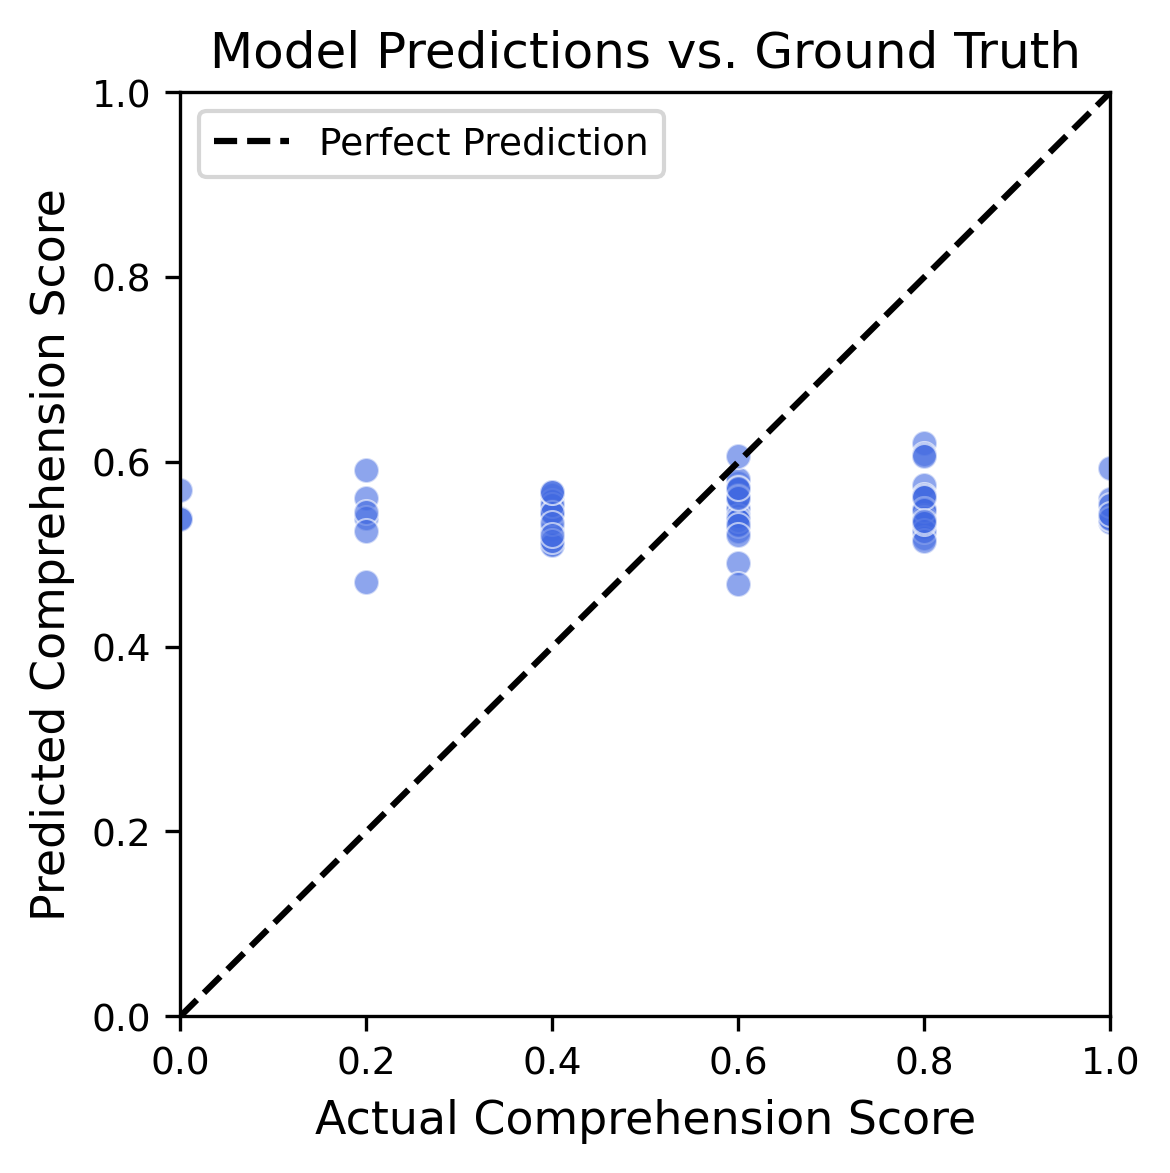

In [ ]:
y_pred = final_model.predict(X_test_pca).flatten()

plt.figure(figsize=(4, 4))
plt.scatter(y_test_pca, y_pred, alpha=0.6, color='royalblue', edgecolors='w', linewidth=0.5)
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect Prediction')

plt.xlabel("Actual Comprehension Score")
plt.ylabel("Predicted Comprehension Score")
plt.title("Model Predictions vs. Ground Truth")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc='upper left')

plt.savefig("actual_vs_predicted.pdf", bbox_inches='tight')
plt.show()

/tmp/ipykernel_552/789718485.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rmses, y=features, palette="viridis")


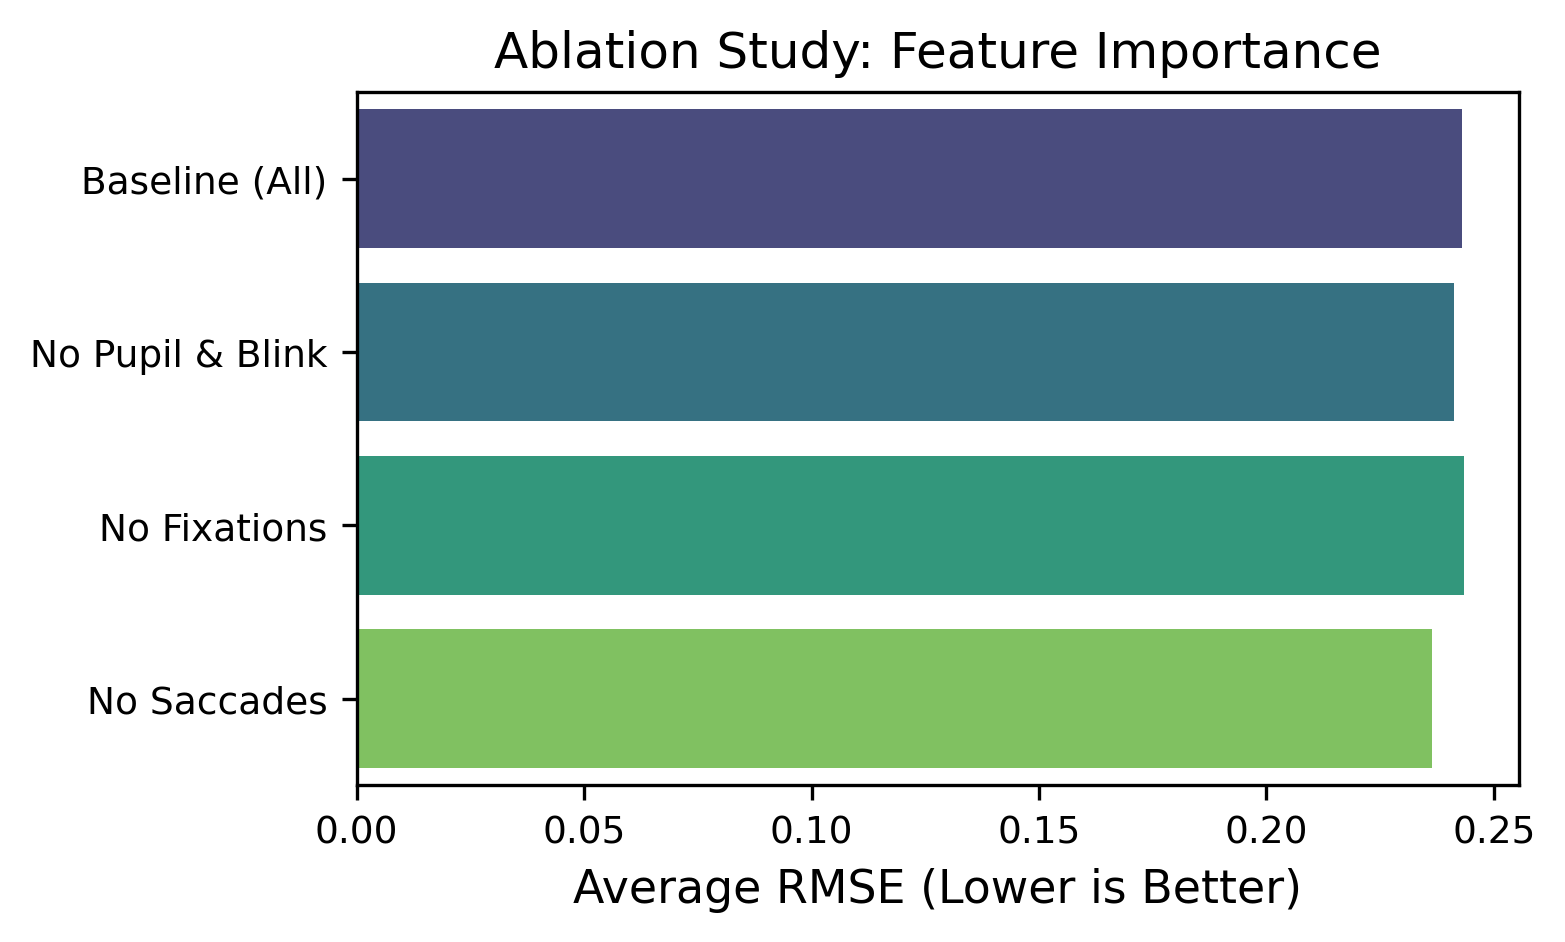

In [ ]:
features = ['Baseline (All)', 'No Pupil & Blink', 'No Fixations', 'No Saccades']
rmses = [
    avg_rmse_pca,
    ablation_results['Pupil & Blink']['RMSE'],
    ablation_results['Fixations']['RMSE'],
    ablation_results['Saccades']['RMSE']
]

plt.figure(figsize=(5, 3))
sns.barplot(x=rmses, y=features, palette="viridis")

plt.xlabel("Average RMSE (Lower is Better)")
plt.title("Ablation Study: Feature Importance")

plt.savefig("ablation_bar_chart.pdf")
plt.show()

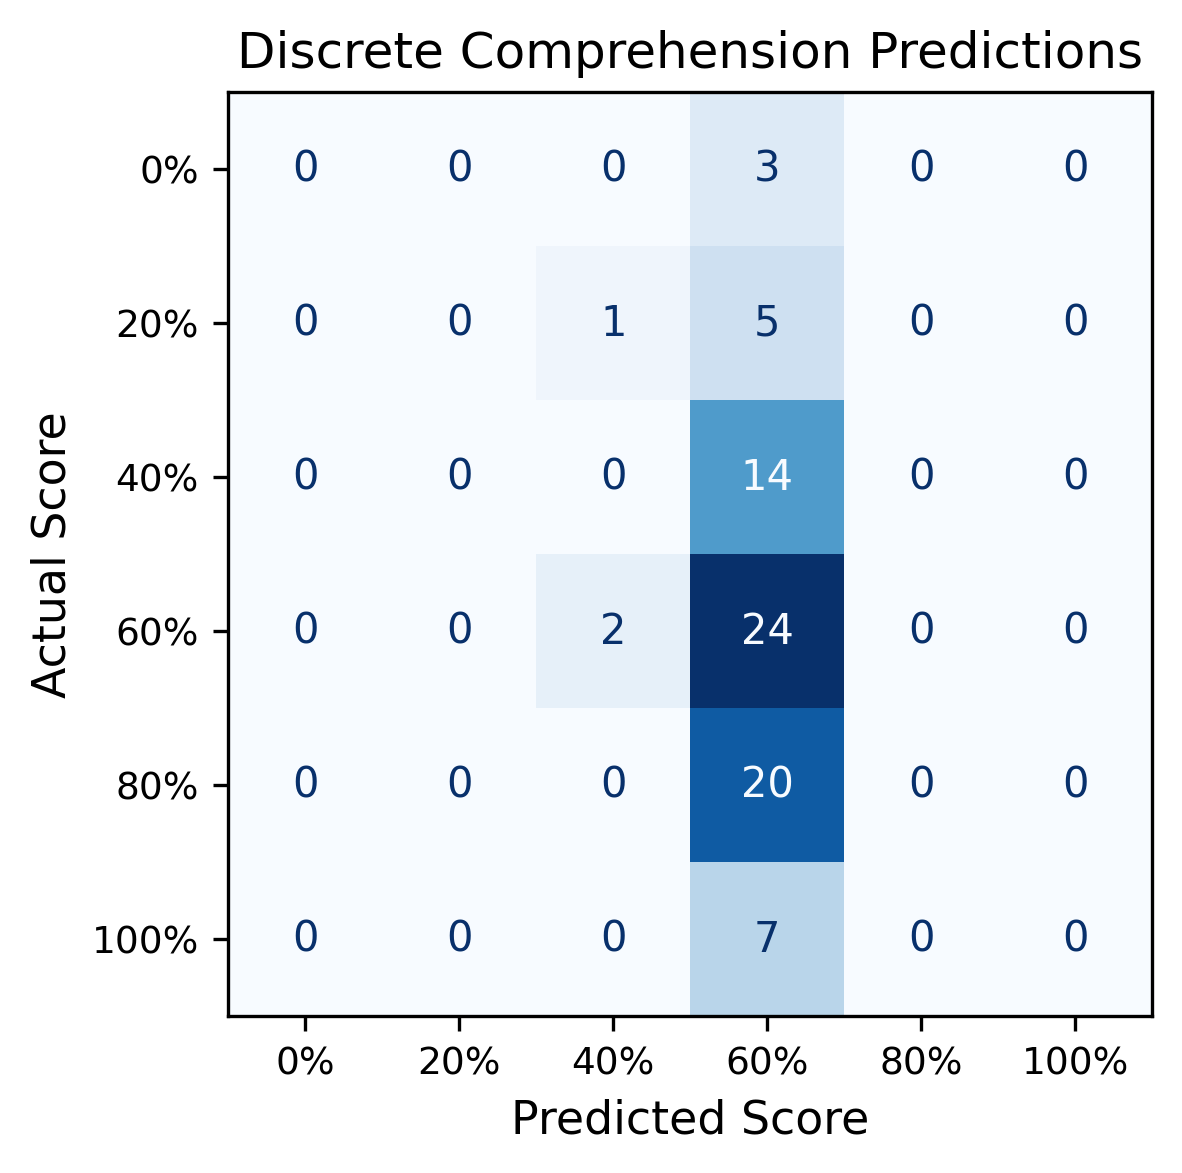

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Discretize continuous ratio predictions back into original integer class bins (0 to 5)
y_pred_classes = np.round(y_pred * 5).astype(int)
y_test_classes = np.round(y_test_pca * 5).astype(int)

# Compute confusion matrix across all six possible comprehension outcomes
class_labels = [0, 1, 2, 3, 4, 5]
cm = confusion_matrix(y_test_classes, y_pred_classes, labels=class_labels)

plt.figure(figsize=(4, 4))
display_labels = ["0%", "20%", "40%", "60%", "80%", "100%"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot(cmap='Blues', values_format='d', ax=plt.gca(), colorbar=False)
plt.title("Discrete Comprehension Predictions")
plt.xlabel("Predicted Score")
plt.ylabel("Actual Score")
plt.savefig("confusion_matrix.pdf")
plt.show()

In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Discretize continuous target ratios into 6 ordinal classes (0-5)
y_train_class = np.round(y_train_pca * 5).astype(int)
y_test_class = np.round(y_test_pca * 5).astype(int)

# Computing inverse frequency class weights to fix the dataset class imbalance
unique_classes = np.unique(y_train_class)
weights_array = compute_class_weight(class_weight='balanced', classes=unique_classes, y=y_train_class)
class_weights = {cls: weight for cls, weight in zip(unique_classes, weights_array)}

# Printing the distribution to see the imbalance
print("=== CLASS DISTRIBUTION (TRAIN) ===")
for cls, count in zip(unique_classes, np.bincount(y_train_class)):
    score_percentage = int((cls / 5.0) * 100)
    print(f"Score {score_percentage}% (Class {cls}): {count} readers -> Weight: {class_weights[cls]:.2f}")

=== CLASS DISTRIBUTION (TRAIN) ===
Score 0% (Class 0): 6 readers -> Weight: 8.44
Score 20% (Class 1): 36 readers -> Weight: 1.41
Score 40% (Class 2): 84 readers -> Weight: 0.60
Score 60% (Class 3): 101 readers -> Weight: 0.50
Score 80% (Class 4): 50 readers -> Weight: 1.01
Score 100% (Class 5): 27 readers -> Weight: 1.88


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Masking, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

def build_classification_rnn(timesteps, features):
    """Constructs a Bi-LSTM architecture for 6-class ordinal prediction."""
    inputs = Input(shape=(timesteps, features))
    x = Masking(mask_value=-999.0)(inputs)
    x = Bidirectional(LSTM(64, return_sequences=True, dropout=0.1))(x)
    x = Bidirectional(LSTM(32, dropout=0.1))(x)
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.1)(x)
    outputs = Dense(6, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print("=== INITIALIZING CLASSIFICATION ARCHITECTURE ===")
timesteps_pca = X_train_pca.shape[1]
features_pca = X_train_pca.shape[2]
classification_model = build_classification_rnn(timesteps_pca, features_pca)
early_stop_clf = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

print("\n=== TRAINING WITH DYNAMIC CLASS WEIGHTS ===")
history_clf = classification_model.fit(
    X_train_pca,
    y_train_class,
    validation_split=0.1,
    epochs=30,
    batch_size=32,
    class_weight=class_weights,
    verbose=1,
    callbacks=[early_stop_clf]
)

print("\n=== FINAL UNSEEN HOLDOUT EVALUATION ===")
test_loss, test_accuracy = classification_model.evaluate(X_test_pca, y_test_class, verbose=1)
print("\n" + "="*40)
print(f"Classification Test Accuracy: {test_accuracy * 100:.2f}%")
print("="*40)

=== INITIALIZING CLASSIFICATION ARCHITECTURE ===

=== TRAINING WITH DYNAMIC CLASS WEIGHTS ===
Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 380ms/step - accuracy: 0.1795 - loss: 1.8711 - val_accuracy: 0.1290 - val_loss: 1.7966
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 219ms/step - accuracy: 0.2637 - loss: 1.7844 - val_accuracy: 0.2581 - val_loss: 1.8031
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 223ms/step - accuracy: 0.2711 - loss: 1.8136 - val_accuracy: 0.2581 - val_loss: 1.8158
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 219ms/step - accuracy: 0.2601 - loss: 1.7973 - val_accuracy: 0.1290 - val_loss: 1.8312
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 217ms/step - accuracy: 0.1795 - loss: 1.7823 - val_accuracy: 0.1290 - val_loss: 1.8769

=== FINAL UNSEEN HOLDOUT EVALUATION ===
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 196ms/step - accuracy: 0.2237 - loss: 1.7585

Classification Test Accuracy: 22.37%
